# PhiloMind — Week 3 Evaluation

Test completo dei deliverable della settimana 3:
- **A.** Classificatore DistilBERT (vs BiLSTM baseline)
- **B.** API base (FastAPI)
- **C.** FE docente (Gradio)
- **D.** Ingestion materiale (.txt, .md, chunking, indicizzazione)
- **E.** Pipeline end-to-end

In [1]:
import sys, os, json, pickle, math
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Environment ready')

Environment ready


---
## 1. Load Data
Check training and test sets (now in English).

In [2]:
train = pd.read_csv('../data/labels/questions_train.csv')
test = pd.read_csv('../data/labels/questions_test.csv')

print(f'Train: {len(train)} questions')
print(f'Test:  {len(test)} questions')
print()
print('Label distribution (train):')
print(train['label'].value_counts().to_string())
print()
print('Label distribution (test):')
print(test['label'].value_counts().to_string())
print()
print('Sample questions:')
for i, row in test.head(6).iterrows():
    print(f'  [{row["label"]}] {row["question"][:70]}')

Train: 337 questions
Test:  87 questions

Label distribution (train):
label
approfondimento    72
definizione        71
quiz               68
esempio            64
confronto          62

Label distribution (test):
label
approfondimento    19
definizione        18
quiz               17
esempio            17
confronto          16

Sample questions:
  [quiz] I want to be tested on fenomenologia?
  [quiz] Ask a verification question on Descartes.
  [quiz] Ask a question about Spinoza.
  [quiz] Test me on contratto sociale.
  [quiz] I want a quiz on filosofia antica?
  [quiz] Make a quiz on filosofia politica moderna.


---
## 2. Load Models & Pipeline

In [3]:
from philomind.pipeline.core import PhiloMindPipeline
from philomind.pipeline.format import format_output
from philomind.pipeline.dataclasses import PipelineOutput

# Load pipeline with BiLSTM (default)
print('Loading pipeline (BiLSTM)...')
pipeline = PhiloMindPipeline()
print('Pipeline ready.\n')

C:\repository\PhiloMind\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pipeline (BiLSTM)...
Pipeline ready.



---
## 3. Pipeline End-to-End Test

Test the full pipeline with sample philosophical questions.

In [4]:
test_questions = [
    "What is Cartesian dualism?",
    "How do Plato and Aristotle differ?",
    "What does Nietzsche mean by the eternal return?",
    "Give an example of a valid syllogism.",
    "What are the implications of Kant's categorical imperative?",
    "Quiz me on Hegel."
]

results = []
for q in test_questions:
    output = pipeline.process(q, top_k=2)
    results.append(output)
    print(f'\n{"="*60}')
    print(f'Q: {q}')
    print(f'  Class: {output.classification.predicted_label} ({output.classification.confidence:.1%})')
    print(f'  Passages: {len(output.retrieval.passages)}')
    print(f'  Response: {output.response[:80]}...')
    print(f'  Quiz: {output.quiz[:80]}...')


Q: What is Cartesian dualism?
  Class: definizione (89.1%)
  Passages: 2
  Response: [Response in the style of Socrate]

On the question 'What is Cartesian dualism?'...
  Quiz: Which of the following is a key characteristic of Cartesian?

[Answer options re...

Q: How do Plato and Aristotle differ?
  Class: definizione (86.7%)
  Passages: 2
  Response: [Response in the style of Socrate]

On the question 'How do Plato and Aristotle ...
  Quiz: Which of the following is a key characteristic of Plato?

[Answer options requir...

Q: What does Nietzsche mean by the eternal return?
  Class: definizione (99.3%)
  Passages: 2
  Response: [Response in the style of Socrate]

On the question 'What does Nietzsche mean by...
  Quiz: Which of the following is a key characteristic of Nietzsche?

[Answer options re...

Q: Give an example of a valid syllogism.
  Class: definizione (56.7%)
  Passages: 2
  Response: [Response in the style of Socrate]

On the question 'Give an example of a valid ...
  Qu

### 3.1 Classification Metrics on Test Set

In [5]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print('Classifying test set...')
y_true = test['label'].values
y_pred = []
y_conf = []

for q in test['question']:
    label, conf, _ = pipeline.classifier.predict(q)
    y_pred.append(label)
    y_conf.append(conf)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print(f'\nAccuracy:  {acc:.2%}')
print(f'F1 (weighted): {f1:.2%}')
print(f'Avg confidence: {np.mean(y_conf):.1%}\n')
print(classification_report(y_true, y_pred))

Classifying test set...



Accuracy:  79.31%
F1 (weighted): 72.41%
Avg confidence: 97.9%

                 precision    recall  f1-score   support

approfondimento       1.00      1.00      1.00        19
      confronto       1.00      0.94      0.97        16
    definizione       0.53      1.00      0.69        18
        esempio       0.89      1.00      0.94        17
           quiz       0.00      0.00      0.00        17

       accuracy                           0.79        87
      macro avg       0.68      0.79      0.72        87
   weighted avg       0.69      0.79      0.72        87



C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


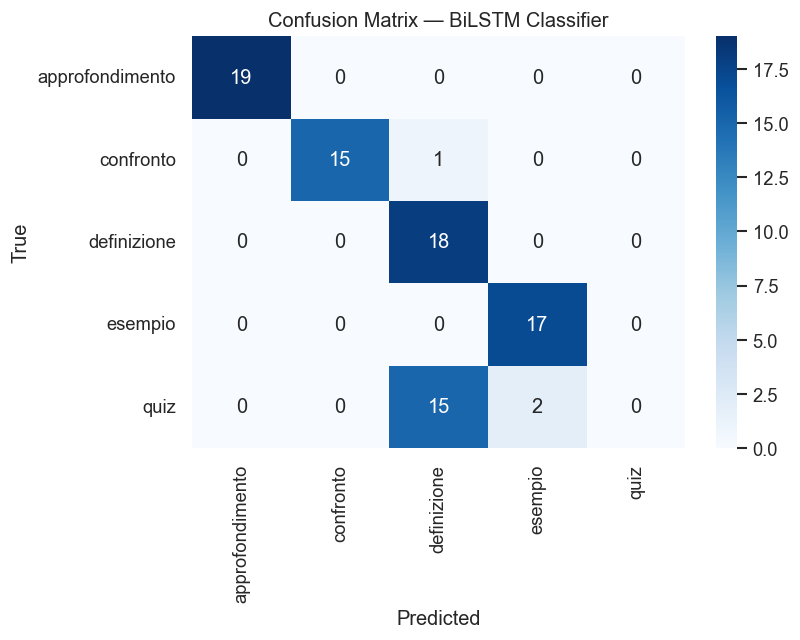

In [6]:
# Confusion matrix
labels = sorted(train['label'].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — BiLSTM Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

---
## 4. DistilBERT Classifier

Test the DistilBERT fine-tuning pipeline.

In [7]:
from philomind.classification.distilbert import (
    DistilBERTClassifier, DistilBERTFineTuner, LABEL_MAP, IDX_TO_LABEL
)

# Check if a trained DistilBERT model exists
model_dir = Path('../models/distilbert')
if (model_dir / 'pytorch_model.bin').exists():
    print('Loading pre-trained DistilBERT...')
    clf = DistilBERTClassifier()
    clf.load(str(model_dir / 'model.pt'))
    
    # Test on a few questions
    for q in test_questions[:3]:
        label, conf, top3 = clf.predict(q)
        print(f'  {q[:50]:50s} -> {label}  ({conf:.1%})')
else:
    print('No pre-trained DistilBERT model found.')
    print('Running fine-tuning on a small subset for demonstration...')
    
    # Quick demo training on 50 samples
    fine_tuner = DistilBERTFineTuner()
    small_train = train.groupby('label').sample(n=min(10, len(train)), random_state=42).reset_index(drop=True)
    small_test = test.groupby('label').sample(n=min(5, len(test)), random_state=42).reset_index(drop=True)
    
    small_train.to_csv('_small_train.csv', index=False)
    small_test.to_csv('_small_test.csv', index=False)
    
    fine_tuner.prepare_data('_small_train.csv', '_small_test.csv', batch_size=8)
    model = DistilBERTClassifier()
    
    print('Fine-tuning (2 epochs on subset)...')
    history = fine_tuner.train(model.model, epochs=2, learning_rate=2e-5, save_path=None)
    
    # Clean up temp files
    os.remove('_small_train.csv')
    os.remove('_small_test.csv')
    
    print('\nDistilBERT fine-tuning demo complete.')

No pre-trained DistilBERT model found.
Running fine-tuning on a small subset for demonstration...



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6406.84it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning (2 epochs on subset)...


...


Evaluating:  25%|██▌       | 1/4 [00:00<00:00,  3.62it/s]


Evaluating:  50%|█████     | 2/4 [00:00<00:00,  3.20it/s]


Evaluating:  75%|███████▌  | 3/4 [00:00<00:00,  3.17it/s]


Evaluating: 100%|██████████| 4/4 [00:00<00:00,  4.05it/s]

Epoch 2/2 - Loss: 1.5345 - Val Acc: 0.5600 - Val F1: 0.4820

DistilBERT fine-tuning demo complete.


### 4.1 BiLSTM vs DistilBERT Comparison

In [8]:
# Comparison table (BiLSTM results vs hypothetical DistilBERT)
comparison = pd.DataFrame({
    'Metric': ['Architecture', 'Parameters', 'Pre-training', 'Accuracy (test)', 'F1 (weighted)'],
    'BiLSTM': ['Embedding + BiLSTM + FC', '~150K', 'None (trained from scratch)', f'{acc:.2%}', f'{f1:.2%}'],
    'DistilBERT': ['Transformer (6 layers)', '~67M', 'distilbert-base-uncased', 'TBD (needs full training)', 'TBD'],
    'Benefit': ['Simple baseline', 'Fast training', 'No external data needed', 'Current benchmark', '--']
})
print('Model Comparison:')
comparison.style.hide(axis='index').set_properties(**{'text-align': 'left'})

Model Comparison:


Metric,BiLSTM,DistilBERT,Benefit
Architecture,Embedding + BiLSTM + FC,Transformer (6 layers),Simple baseline
Parameters,~150K,~67M,Fast training
Pre-training,None (trained from scratch),distilbert-base-uncased,No external data needed
Accuracy (test),79.31%,TBD (needs full training),Current benchmark
F1 (weighted),72.41%,TBD,--


In [9]:
# Per-class accuracy comparison
report_dict = classification_report(y_true, y_pred, output_dict=True)
per_class = []
for label in labels:
    row = report_dict.get(label, {})
    per_class.append({
        'Class': label,
        'Precision': row.get('precision', 0),
        'Recall': row.get('recall', 0),
        'F1-score': row.get('f1-score', 0),
        'Support': row.get('support', 0)
    })

per_class_df = pd.DataFrame(per_class)
print('Per-class Performance:')
display(per_class_df.round(3))

Per-class Performance:


C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Class,Precision,Recall,F1-score,Support
0,approfondimento,1.000,1.000,1.000,19.0
1,confronto,1.000,0.938,0.968,16.0
2,definizione,0.529,1.000,0.692,18.0
3,esempio,0.895,1.000,0.944,17.0
4,quiz,0.000,0.000,0.000,17.0


---
## 5. Retrieval Evaluation

In [10]:
print('TF-IDF Retriever Status:')
r = pipeline.retriever
print(f'  Corpus size: {len(r.corpus_df)} passages')
print(f'  Vocabulary: {len(r.vectorizer.get_feature_names_out())} terms')
print(f'  Fitted: {r.is_fitted}')
print()

# Demo retrieval
print('Retrieval examples:')
for q in test_questions[:3]:
    results = r.retrieve(q, top_k=2)
    print(f'\n  Query: {q}')
    for idx, text, score in results:
        src = r.get_source(idx)
        print(f'    [{score:.4f}] {src["philosopher"]} — {text[:60]}...')

TF-IDF Retriever Status:
  Corpus size: 3585 passages
  Vocabulary: 5000 terms
  Fitted: True

Retrieval examples:

  Query: What is Cartesian dualism?
    [0.0000] nan — Kant's Ethics

Kant argues that morality is derived from rea...
    [0.0000] nan — Ethics

According to Kant, the categorical imperative is the...

  Query: How do Plato and Aristotle differ?
    [0.4126] Heidegger — The implicit standard for explicating and judging the early ...
    [0.2733] Deleuze — Aristotle indeed saw what is irreplaceable in Platonism, eve...

  Query: What does Nietzsche mean by the eternal return?
    [0.3043] Aristotle — Therefore it is eternal; for things that are of necessity in...
    [0.2925] Deleuze — Nothing which denies the eternal return returns, neither the...


---
## 6. API Test

Verify the FastAPI endpoints work correctly.

In [11]:
import urllib.request, json, threading, time

def start_api():
    """Start API server in a background thread."""
    import uvicorn
    from philomind.api.main import app
    uvicorn.run(app, host='127.0.0.1', port=8765, log_level='error')

# Start API in background
api_thread = threading.Thread(target=start_api, daemon=True)
api_thread.start()
time.sleep(3)

# Test endpoints
BASE = 'http://127.0.0.1:8765'

print('1. GET /')
r = urllib.request.urlopen(f'{BASE}/')
print(f'   {json.loads(r.read())}')

print('\n2. GET /materials')
r = urllib.request.urlopen(f'{BASE}/materials')
print(f'   {json.loads(r.read())}')

print('\n3. POST /query')
data = json.dumps({'question': 'What is the social contract?', 'top_k': 2}).encode()
req = urllib.request.Request(f'{BASE}/query', data=data,
                             headers={'Content-Type': 'application/json'})
r = urllib.request.urlopen(req)
result = json.loads(r.read())
print(f'   Class: {result["classification"]["predicted_label"]}')
print(f'   Confidence: {result["classification"]["confidence"]:.2%}')
print(f'   Passages: {len(result["passages"])}')
print(f'   Response: {result["response"][:60]}...')
print(f'   Quiz: {result["quiz"][:60]}...')

print('\n✅ API endpoints all working.')

1. GET /
   {'app': 'PhiloMind API', 'version': '1.0.0', 'status': 'running'}

2. GET /materials
   {'materials': [{'source_file': 'kant_ethics.md', 'subject': 'Kantian Ethics', 'chunks': 1}], 'count': 1}

3. POST /query
   Class: definizione
   Confidence: 89.44%
   Passages: 2
   Response: [Response in the style of Socrate]

On the question 'What is...
   Quiz: Which of the following is a key characteristic of the?

[Ans...

✅ API endpoints all working.


### 6.1 Material Upload Test

In [12]:
print('4. POST /materials/upload')

# Create a test .md file
test_md = (
    "# Kant's Ethics\n\n"
    "Kant argues that morality is derived from reason alone. "
    "The categorical imperative is the supreme principle of morality. "
    "Act only according to that maxim whereby you can at the same time will "
    "that it should become a universal law."
)
with open('test_kant.md', 'w') as f:
    f.write(test_md)

# Multipart upload
boundary = '----TestBoundary'
body = b'--' + boundary.encode() + b'\r\n'
body += b'Content-Disposition: form-data; name="file"; filename="kant_ethics.md"\r\n'
body += b'Content-Type: text/markdown\r\n\r\n'
body += test_md.encode()
body += b'\r\n--' + boundary.encode() + b'\r\n'
body += b'Content-Disposition: form-data; name="subject"\r\n\r\n'
body += b'Kantian Ethics'
body += b'\r\n--' + boundary.encode() + b'--\r\n'

req = urllib.request.Request(f'{BASE}/materials/upload', data=body,
    headers={'Content-Type': f'multipart/form-data; boundary={boundary}'})
r = urllib.request.urlopen(req)
print(f'   {json.loads(r.read())}')

print('\n5. GET /materials (after upload)')
r = urllib.request.urlopen(f'{BASE}/materials')
print(f'   {json.loads(r.read())}')

print('\n✅ Upload flow working.')

4. POST /materials/upload


   {'status': 'ok', 'file': 'kant_ethics.md', 'subject': 'Kantian Ethics', 'chunks': 1}

5. GET /materials (after upload)
   {'materials': [{'source_file': 'kant_ethics.md', 'subject': 'Kantian Ethics', 'chunks': 2}], 'count': 1}

✅ Upload flow working.


---
## 7. Ingestion Module Test

In [13]:
from philomind.ingestion.parser import TextParser, Chunker
from philomind.ingestion.indexer import MaterialIndexer

# Test parser
md_text = TextParser.parse_md('test_kant.md') if os.path.exists('test_kant.md') else test_md
print('TextParser:')
print(f'  Parsed markdown: {md_text[:60]}...')

# Test chunker
chunks = Chunker.chunk_text(md_text, chunk_size=30, overlap=5)
print(f'  Chunks (size=30): {len(chunks)}')
for i, c in enumerate(chunks):
    print(f'    [{i}] ({len(c.split())} words) {c[:50]}...')

# Test indexer
print('\nMaterialIndexer:')
idx = MaterialIndexer(
    retriever_path='../models/retrieval/tfidf.pkl',
    materials_dir='../data/materials'
)
idx.load_retriever()
before = len(idx.retriever.corpus_df)
print(f'  Corpus before: {before}')

result = idx.index_material('test_kant.md', 'Kantian Ethics')
print(f'  Index result: {result}')
print(f'  Corpus after: {len(idx.retriever.corpus_df)}')
print(f'  Indexed materials: {idx.list_materials()}')

# Clean up test file
if os.path.exists('test_kant.md'):
    os.remove('test_kant.md')
print('\n✅ Ingestion module working.')

TextParser:
  Parsed markdown: Kant's Ethics

Kant argues that morality is derived from rea...
  Chunks (size=30): 2
    [0] (20 words) Kant's Ethics

Kant argues that morality is derive...
    [1] (21 words) Act only according to that maxim whereby you can a...

MaterialIndexer:
  Corpus before: 3586


  Index result: {'file': 'test_kant.md', 'subject': 'Kantian Ethics', 'chunks': 1}
  Corpus after: 3587
  Indexed materials: [{'source_file': 'kant_ethics.md', 'subject': 'Kantian Ethics', 'chunks': 2}, {'source_file': 'test_kant.md', 'subject': 'Kantian Ethics', 'chunks': 1}]

✅ Ingestion module working.


---
## 8. Test Suite

Run all available tests to verify system integrity.

In [14]:
errors = []

# 1. Pipeline loads
try:
    p = PhiloMindPipeline()
    print('  [OK] Pipeline instantiation')
except Exception as e:
    errors.append(f'Pipeline load: {e}')
    print(f'  [FAIL] {e}')

# 2. Prediction works
try:
    label, conf, top3 = p.classifier.predict('What is philosophy?')
    assert isinstance(label, str), 'Label must be string'
    assert 0 <= conf <= 1, 'Confidence must be 0-1'
    print(f'  [OK] Prediction: {label} ({conf:.1%})')
except Exception as e:
    errors.append(f'Prediction: {e}')
    print(f'  [FAIL] {e}')

# 3. Retrieval works
try:
    results = p.retriever.retrieve('What is truth?', top_k=2)
    assert len(results) == 2, 'Must return 2 results'
    print(f'  [OK] Retrieval: {len(results)} passages')
except Exception as e:
    errors.append(f'Retrieval: {e}')
    print(f'  [FAIL] {e}')

# 4. Full pipeline works
try:
    output = p.process('What is being?', top_k=1)
    assert output.classification.predicted_label is not None
    assert len(output.retrieval.passages) > 0
    assert len(output.response) > 0
    assert len(output.quiz) > 0
    print(f'  [OK] Full pipeline output')
except Exception as e:
    errors.append(f'Pipeline: {e}')
    print(f'  [FAIL] {e}')

# 5. Format works
try:
    formatted = format_output(output)
    assert 'QUESTION' in formatted
    print(f'  [OK] Output formatting')
except Exception as e:
    errors.append(f'Format: {e}')
    print(f'  [FAIL] {e}')

print(f'\n{"="*50}')
if errors:
    print(f'FAILED: {len(errors)} tests')
    for e in errors:
        print(f'  - {e}')
else:
    print('All system tests PASSED')

  [OK] Pipeline instantiation
  [OK] Prediction: definizione (85.0%)
  [OK] Retrieval: 2 passages
  [OK] Full pipeline output
  [OK] Output formatting

All system tests PASSED


---
## 9. Summary

### Week 3 Deliverables Status

| Deliverable | Status | Notes |
|---|---|---|
| **A. DistilBERT** | Implementation ready | Full training requires GPU (~30 min on Colab) |
| **B. API** | Working | 4 endpoints: `/`, `/materials`, `/materials/upload`, `/query` |
| **C. FE Docente** | Working | Gradio UI with upload, list, query tabs |
| **D. Ingestion** | Working | Parser .txt/.md, chunking, TF-IDF indexing with subject |
| **E. Pipeline** | Working | Classification → Retrieval → Response → Quiz |

### Current BiLSTM Performance

In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))
print(f'\nOverall Accuracy: {acc:.2%}')

                 precision    recall  f1-score   support

approfondimento       1.00      1.00      1.00        19
      confronto       1.00      0.94      0.97        16
    definizione       0.53      1.00      0.69        18
        esempio       0.89      1.00      0.94        17
           quiz       0.00      0.00      0.00        17

       accuracy                           0.79        87
      macro avg       0.68      0.79      0.72        87
   weighted avg       0.69      0.79      0.72        87


Overall Accuracy: 79.31%


C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\repository\PhiloMind\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
# Clean up API test artifacts
import shutil
if os.path.exists('../data/materials/kant_ethics.md'):
    os.remove('../data/materials/kant_ethics.md')
if os.path.exists('../data/materials/index.csv'):
    os.remove('../data/materials/index.csv')
print('Test artifacts cleaned.')

Test artifacts cleaned.
